[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/01_baseline_pytorch.ipynb)

# 01. Simple Binary Classification (Baseline MLP) — PyTorch

The simplest network: one hidden layer, sigmoid output, Adam. We write the full training loop by hand so every step is visible.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

> This is the PyTorch twin of `01_..._keras.ipynb`. Where Keras hides the training loop inside `model.fit`, here we **write the loop explicitly** — that is the main thing to compare.

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

Features are already scaled to `[0,1]`; we drop the ID and do a **stratified** split.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
# Wrap the numpy arrays as float tensors. Target is shaped (N,1) to match the
# sigmoid output and BCELoss.
Xtr = torch.tensor(X_train)
ytr = torch.tensor(y_train).view(-1, 1)
Xte = torch.tensor(X_test)
yte = torch.tensor(y_test).view(-1, 1)
print("Xtr", tuple(Xtr.shape), "| ytr", tuple(ytr.shape))

Xtr (491, 11) | ytr (491, 1)


In [5]:
def train_model(model, optimizer, epochs=100, batch_size=32, clip=None, loss_fn=None):
    """Train `model`, returning a Keras-style history dict so we can reuse plot_history."""
    if loss_fn is None:
        loss_fn = nn.BCELoss()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    hist = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip)   # gradient clipping
            optimizer.step()
        # end-of-epoch metrics on the full train & test sets
        model.eval()
        with torch.no_grad():
            tr, te = model(Xtr), model(Xte)
            hist["loss"].append(loss_fn(tr, ytr).item())
            hist["val_loss"].append(loss_fn(te, yte).item())
            hist["accuracy"].append((((tr > 0.5) == (ytr > 0.5)).float().mean()).item())
            hist["val_accuracy"].append((((te > 0.5) == (yte > 0.5)).float().mean()).item())
    return hist

In [6]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test (dashed) loss and accuracy over epochs."""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["loss"], label="train")
    ax[0].plot(hist["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["accuracy"], label="train")
    ax[1].plot(hist["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A minimal MLP

`nn.Sequential` stacks layers. The final `nn.Sigmoid` turns the logit into a probability, matched with `nn.BCELoss` (binary cross-entropy).

In [7]:
def build_baseline():
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(N_FEATURES, 16),
        nn.ReLU(),
        nn.Linear(16, 1),
        nn.Sigmoid(),
    )

model = build_baseline()
print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Sequential(
  (0): Linear(in_features=11, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)
Trainable params: 209


## 5. Train

Each epoch: loop over mini-batches → forward → `loss.backward()` → `optimizer.step()`. Compare this with Keras' single `model.fit` call.

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history = train_model(model, optimizer, epochs=100, batch_size=32)
print("Final: train acc = %.3f | test acc = %.3f" %
      (history["accuracy"][-1], history["val_accuracy"][-1]))

Final: train acc = 0.800 | test acc = 0.862


## 6. Train vs test curves

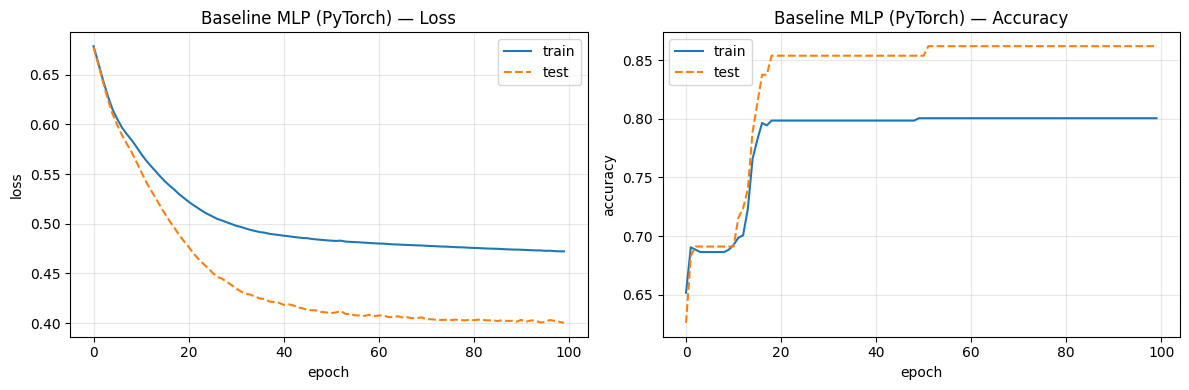

In [9]:
plot_history(history, "Baseline MLP (PyTorch)")

## 7. Evaluate

In [10]:
model.eval()
with torch.no_grad():
    prob = model(Xte)
    acc = (((prob > 0.5) == (yte > 0.5)).float().mean()).item()
    loss = nn.BCELoss()(prob, yte).item()
print("Test loss: %.4f | Test accuracy: %.4f" % (loss, acc))

Test loss: 0.4003 | Test accuracy: 0.8618


## 8. Confusion matrix & ROC curve

Accuracy alone hides *how* the model is wrong. The **confusion matrix** shows the four outcomes; the **ROC curve** and its **AUC** summarise performance across every threshold. We pull the probabilities out of the tensor with `.numpy()`.

              precision    recall  f1-score   support

Rejected (0)       0.96      0.58      0.72        38
Approved (1)       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



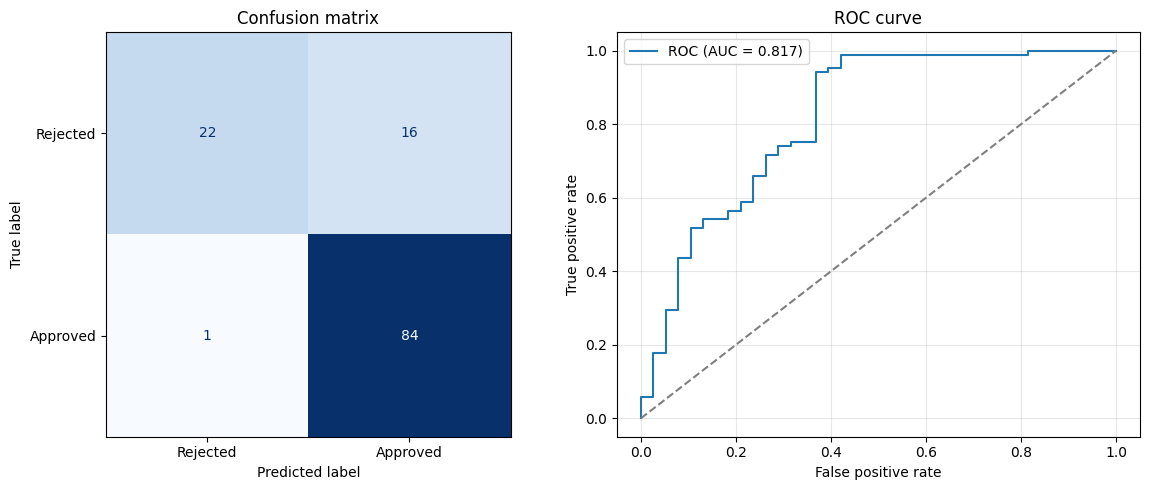

AUC = 0.817


In [11]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)

model.eval()
with torch.no_grad():
    y_prob = model(Xte).ravel().numpy()
y_true = yte.ravel().numpy()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(
    ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label="ROC (AUC = %.3f)" % roc_auc)
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("AUC = %.3f" % roc_auc)

## Takeaways
- The explicit loop (`zero_grad → forward → backward → step`) is exactly what Keras' `fit` does internally.
- Once you have probabilities as a NumPy array, **all of scikit-learn's metrics work the same** regardless of framework — confusion matrix, ROC, AUC are framework-agnostic.
- Remember `model.eval()` before scoring, so Dropout/BatchNorm (added in later notebooks) behave in inference mode.
- `model.train()` vs `model.eval()` matters once you add Dropout/BatchNorm — they behave differently in the two modes.
- We reuse a `history` dict so the *same* `plot_history` works for both frameworks — the metrics are identical, only the plumbing differs.
- **Next:** `02_optimizers_pytorch` — swap `torch.optim.*` and compare.